In [2]:
import numpy as np

# ============================================================
# Constants (cgs)
# ============================================================
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# ============================================================
# User / model parameters (toy Dullemond-like)
# ============================================================
Teff   = 3000.0
Rstar  = 2.0 * RSUN

Sigma_1AU = 10.
pSigma    = 1.0

R = 50 * AU
Sigma = Sigma_1AU * (R / AU) ** (-pSigma)

# Prescribed Gaussian density scale height (NOT iterated)
Hscale = 0.1 * R

# Eddington/Marshak boundary parameter (Two stream approximation)
psi = 1.0 / np.sqrt(3.0)

# Grazing beam
mu0 = 0.05

# Grid
nz = 800
zmax = 12.0 * Hscale
p_stretch = 1.0  # cluster points toward surface
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

# Density profile (upper half)
rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5 * (z/Hscale)**2)

# ============================================================
# Opacity model (placeholder power laws)
# ============================================================
Tref = 100.0
kappaP0 = 100.0
kappaR0 = 100.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

# Stellar absorption opacity (placeholder)
kappa_star = kappaP(Teff)


def stellar_heating_q(rho, z, kappa_star, F_star, mu0):
    """
    Simple 1D attenuated grazing beam from +z:
        tau(z) = ∫_z^∞ rho kappa_star dz'
        q(z) = rho kappa_star F_star * exp(-tau/mu0)
    (Units: erg cm^-3 s^-1)

    This is a simplified 'direct irradiation' heating profile.
    """
    # optical depth from top downward (compute on upper-half grid)
    # tau_top[i] = ∫_{z[i]}^{zmax} rho*kappa dz
    integrand = rho * kappa_star
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(z)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z[i+1]-z[i])

    q = rho * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-6))
    return q, tau_top


# ============================================================
# Main solver: eigenvalue integration for J,H + explicit T update
# ============================================================
def solve_column(
    max_iter=300,
    tol=1e-6,
    omega_T=0.2,      # under-relaxation for T (smaller for inner radii)
    Tmin=1.0,
    Tmax=8000.0,
    rho_floor=1e-80,
    kap_floor=1e-20,
    verbose=True
):
    # heating (fixed because rho fixed in this toy)
    # Stellar flux at radius R (normal incidence)
    F_star = (Rstar/R)**2 * SIGMA_SB * Teff**4  # erg/cm^2/s
    q, tau = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

    # initial guess
    T = 150.0 * np.ones_like(z)

    for it in range(max_iter):
        Told = T.copy()

        # Opacities from last iterate
        kapR = np.maximum(kappaR(T), kap_floor)
        kapP_old = np.maximum(kappaP(T), kap_floor)  # lagged kappa_P

        # ------------------------------------------------------------
        # (1) Integrate H from midplane using dH/dz = q/(4π), H(0)=0
        # ------------------------------------------------------------
        Hmom = np.zeros_like(z)
        for i in range(1, len(z)):
            Hmom[i] = Hmom[i-1] + 0.5*(q[i]+q[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # ------------------------------------------------------------
        # (2) Compute eigenvalue J0 from surface BC: H(zmax) = psi J(zmax)
        # dJ/dz = -3 rho kappa_R H  ->  J(zmax) = J0 - ∫ 3 rho kappa_R H dz
        # => J0 = Hs/psi + ∫ 3 rho kappa_R H dz
        # ------------------------------------------------------------
        integrand = 3.0 * rho * kapR * Hmom
        I = np.trapz(integrand, z)
        Hs = Hmom[-1]
        J0 = Hs/psi + I
        J0 = max(J0, 0.0)

        # ------------------------------------------------------------
        # (3) Integrate J upward: dJ/dz = -3 rho kappa_R H, with J(0)=J0
        # ------------------------------------------------------------
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, len(z)):
            dJdz_L = -3.0 * rho[i-1] * kapR[i-1] * Hmom[i-1]
            dJdz_R = -3.0 * rho[i]   * kapR[i]   * Hmom[i]
            J[i] = J[i-1] + 0.5*(dJdz_L + dJdz_R)*(z[i]-z[i-1])

        # clip any tiny negative numerical noise
        J = np.maximum(J, 0.0)

        # ------------------------------------------------------------
        # (4) Explicit T update (lagged kappa_P):
        #     (σ/π) T^4 = J + q/(4π ρ κP(T_old))
        # ------------------------------------------------------------
        rho_eff = np.maximum(rho, rho_floor)
        source = J + q / (4.0*PI*rho_eff*kapP_old)
        source = np.maximum(source, 0.0)

        T_explicit = ((PI / SIGMA_SB) * source) ** 0.25
        T_explicit = np.clip(T_explicit, Tmin, Tmax)

        # under-relaxation
        T = (1.0 - omega_T) * T + omega_T * T_explicit
        T = np.clip(T, Tmin, Tmax)

        # ------------------------------------------------------------
        # convergence + diagnostics
        # ------------------------------------------------------------
        rel = np.max(np.abs((T - Told) / np.maximum(Told, 1.0)))

        if verbose and (it % 10 == 0 or rel < tol):
            Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough
            print(
                f"iter={it:4d} rel={rel:.3e}  "
                f"Tmid={T[0]:.2f}  Tsfc={T[-1]:.2f}  "
                f"minJ={J.min():.3e} maxJ={J.max():.3e}  "
                f"Hs={Hs:.3e} J0={J0:.3e}  "
                f"minq={q.min():.3e} maxq={q.max():.3e}"
            )

        if rel < tol:
            break

    # mirror to full z (optional)
    #z_full = np.concatenate((-z[:0:-1], z))
    #T_full = np.concatenate((T[:0:-1], T))
    #J_full = np.concatenate((J[:0:-1], J))
    #rho_full = np.concatenate((rho[:0:-1], rho))
    #q_full = np.concatenate((q[:0:-1], q))
    #H_full = np.concatenate((-Hmom[:0:-1], Hmom))  # antisymmetric

    return z, rho, q, Hmom, J, T, tau

# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    zf, rhof, qf, Hf, Jf, Tf,tau_star = solve_column(
        max_iter=400,
        tol=1e-6,
        omega_T=0.15,   # try 0.1–0.3; smaller is safer for inner radii
        verbose=True
    )
    mid = len(zf)//2
    print("\nDone.")
    print(f"Midplane: T={Tf[mid]:.2f} K, J={Jf[mid]:.3e}")


iter=   0 rel=1.343e-01  Tmid=129.86  Tsfc=136.69  minJ=1.095e+00 maxJ=1.100e+00  Hs=6.322e-01 J0=1.100e+00  minq=0.000e+00 maxq=1.566e-13
iter=  10 rel=9.411e-02  Tmid=38.18  Tsfc=81.92  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  20 rel=3.735e-02  Tmid=20.13  Tsfc=74.34  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  30 rel=9.193e-03  Tmid=16.57  Tsfc=73.37  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  40 rel=1.904e-03  Tmid=15.87  Tsfc=73.25  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  50 rel=3.786e-04  Tmid=15.73  Tsfc=73.24  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  60 rel=7.469e-05  Tmid=15.71  Tsfc=73.23  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  70 rel=1.471e-05  Tmid=15.70  Ts

/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_76837/2226016048.py:126: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(integrand, z)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_76837/2226016048.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough


In [3]:
idx_tau_star_1 = np.argmin(np.abs(tau_star - 1.0 ))

[]

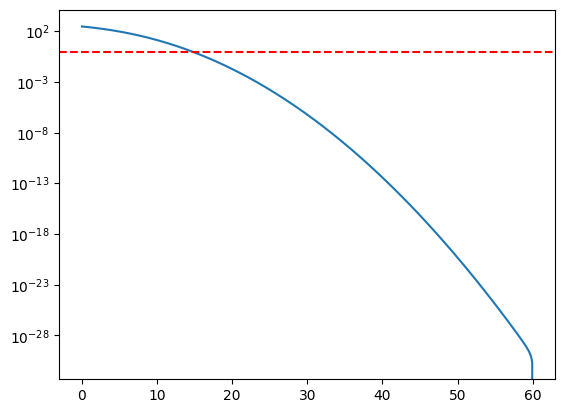

In [5]:
import matplotlib.pyplot as plt
plt.plot(z/AU, tau_star)
plt.axhline(y=1, color='r', linestyle='--')

plt.semilogy()

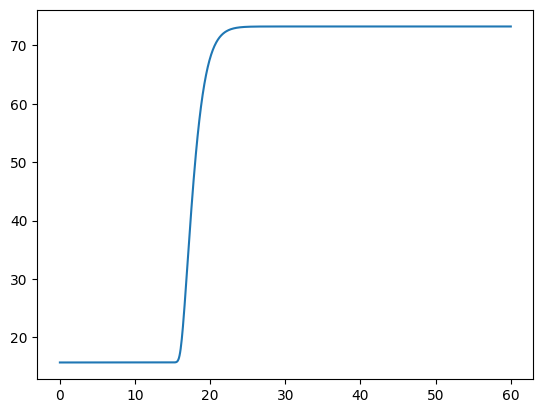

In [4]:
plt.plot(z/AU, Tf)

In [13]:
import numpy as np

# -----------------------------
# Constants (cgs)
# -----------------------------
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # a_R

def _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT=False):
    T0 = np.asarray(T0, float)
    kapP = np.asarray(kappaP_func(T0), float)

    if include_dkappa_dT:
        eps = 1e-3
        Tp = T0*(1+eps)
        Tm = T0*(1-eps)
        dk_dT = (kappaP_func(Tp) - kappaP_func(Tm)) / np.maximum(Tp-Tm, 1e-99)
        denom = 16.0*SIGMA_SB*kapP*T0**3 + 4.0*SIGMA_SB*dk_dT*T0**4
    else:
        denom = 16.0*SIGMA_SB*kapP*T0**3

    t_rad = c_d / np.maximum(denom, 1e-200)
    return Omega * t_rad

def _lambda_levermore_pomraning(R):
    """
    Levermore & Pomraning flux limiter:
      lambda(R) = (1/R) * (coth R - 1/R)
    with stable small-R expansion.
    """
    R = np.asarray(R, float)
    lam = np.empty_like(R)

    small = R < 1e-3
    # series: coth R ~ 1/R + R/3 - R^3/45 ...
    # => lambda ~ 1/3 - R^2/45 + ...
    lam[small] = 1.0/3.0 - (R[small]**2)/45.0

    Rs = R[~small]
    # coth = cosh/sinh
    coth = np.cosh(Rs) / np.sinh(Rs)
    lam[~small] = (coth - 1.0/np.maximum(Rs, 1e-300)) / np.maximum(Rs, 1e-300)

    # enforce bounds: 0 < lambda <= 1
    lam = np.clip(lam, 0.0, 1.0)
    return lam


def lambda_LP_stable(R):
    """
    Levermore-Pomraning limiter:
      lambda(R) = (1/R) * (coth R - 1/R)

    Stable evaluation:
      - small R: series expansion
      - moderate R: use coth = 1 + 2/(exp(2R)-1) via expm1
      - large R: asymptotic lambda ~ 1/R
    """
    R = np.asarray(R, float)
    lam = np.empty_like(R)

    # small-R series
    small = R < 1e-3
    lam[small] = 1.0/3.0 - (R[small]**2)/45.0 + 2.0*(R[small]**4)/945.0

    # large-R asymptotic: coth->1, lambda ~ 1/R
    large = R > 50.0
    lam[large] = 1.0/np.maximum(R[large], 1e-300)

    # moderate-R: use expm1 safely
    mid = (~small) & (~large)
    Rm = R[mid]
    # coth = 1 + 2/(exp(2R)-1) = 1 + 2/expm1(2R)
    coth = 1.0 + 2.0/np.maximum(np.expm1(2.0*Rm), 1e-300)
    lam[mid] = (coth - 1.0/np.maximum(Rm, 1e-300)) / np.maximum(Rm, 1e-300)

    # clip
    lam = np.clip(lam, 0.0, 1.0/3.0)
    return lam


def solve_master_mode_shooting_fld(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    A_shadow=0.2,
    gamma_g=1.4,
    c_d=1.0e7,
    beta_col_d=None,
    beta_col_g=None,
    beta_rad_d=None,
    include_dkappa_dT=False,
    psi=1.0/np.sqrt(3.0),
    use_shadow_heating=True,
    verbose=False,
    # FLD outer iteration controls:
    max_fld_iter=50,
    fld_tol=1e-4,
    omega_lam=0.3,     # under-relax limiter updates
    lam_floor=1e-6,
):
    """
    Self-consistent FLD version of your shooting solver.

    We iterate on lambda(R) profile:
      D_FLD(z) = c * lambda(R) / (rho kappa_R)
    with
      R = |grad E| / (rho kappa_R |E|)
      |grad E| = sqrt( |dE/dz|^2 + (m/R)^2 |E|^2 )

    Inner solve per iteration is your linear shooting system for (E,Fz):
      dE/dz  = -Fz / D_FLD
      dFz/dz = chi*(eta*Td - E) - D_FLD*(m^2/R^2)*E

    where Td(E) is the same algebraic closure you already use.
    """

    z = np.asarray(z, float)
    rho_g = np.asarray(rho_g, float)
    rho_d = np.asarray(rho_d, float)
    T0 = np.asarray(T0, float)
    Q0 = np.asarray(Q0, float)
    nz = len(z)
    if nz < 3:
        raise ValueError("Need at least 3 z points.")
    if not np.all(np.diff(z) > 0):
        raise ValueError("z must be strictly increasing (upper half).")

    m = int(m)
    ig = 1j

    if beta_col_d is None or beta_col_g is None:
        raise ValueError("Please provide beta_col_d(z) and beta_col_g(z).")
    beta_col_d = np.asarray(beta_col_d, float)
    beta_col_g = np.asarray(beta_col_g, float)

    if beta_rad_d is None:
        beta_rad_d = _compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT)
    else:
        beta_rad_d = np.asarray(beta_rad_d, float)

    # background opacities
    kapP0 = np.asarray(kappaP_func(T0), float)
    kapR0 = np.asarray(kappaR_func(T0), float)

    # floors
    rho_eff = np.maximum(rho_d, 1e-99)
    kapR_eff = np.maximum(kapR0, 1e-99)
    kapP_eff = np.maximum(kapP0, 1e-99)

    # coefficients
    chi = rho_eff * kapP_eff * C_LIGHT               # [1/s]
    eta = 4.0 * A_RAD * T0**3                        # [erg cm^-3 K^-1]

    # heating mode amplitude
    if use_shadow_heating:
        Qm = 0.5 * A_shadow * Q0
    else:
        Qm = Q0.copy()

    Theta = Qm / (rho_eff * c_d * Omega)             # [K]

    # --- algebraic Td(E), Tg(E) ---
    def Td_Tg_from_E_with_Theta(E, i, Theta_loc):
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g[i]
        D_T = (ig*m
               + 1.0/beta_rad_d[i]
               + (ig*m*gamma_g*beta_col_g[i]) / (beta_col_d[i] * denom_g))
        Td = (Theta_loc + (1.0/beta_rad_d[i]) * (E/eta[i])) / D_T
        Tg = Td / denom_g
        return Td, Tg

    # ---- RK4 integrator for y=[E,Fz] given a D_FLD(z) profile ----
    def rhs(i, E, Fz, Dfld, forcing_on=True):
        Theta_loc = Theta[i] if forcing_on else 0.0
        Td, _Tg = Td_Tg_from_E_with_Theta(E, i, Theta_loc)

        dE_dz  = -Fz / Dfld[i]
        dFz_dz = chi[i]*(eta[i]*Td - E) - Dfld[i] * (m**2)/(R**2) * E
        return dE_dz, dFz_dz

    def integrate(E0, Dfld, forcing_on=True):
        E = np.zeros(nz, dtype=complex)
        F = np.zeros(nz, dtype=complex)
        E[0] = E0
        F[0] = 0.0 + 0.0j  # midplane symmetry

        for i in range(nz-1):
            dz = z[i+1] - z[i]
            E_i, F_i = E[i], F[i]

            k1E, k1F = rhs(i, E_i, F_i, Dfld, forcing_on=forcing_on)

            E_half = E_i + 0.5*dz*k1E
            F_half = F_i + 0.5*dz*k1F
            k2E_i, k2F_i = rhs(i,   E_half, F_half, Dfld, forcing_on=forcing_on)
            k2E_p, k2F_p = rhs(i+1, E_half, F_half, Dfld, forcing_on=forcing_on)
            k2E, k2F = 0.5*(k2E_i + k2E_p), 0.5*(k2F_i + k2F_p)

            E_half2 = E_i + 0.5*dz*k2E
            F_half2 = F_i + 0.5*dz*k2F
            k3E_i, k3F_i = rhs(i,   E_half2, F_half2, Dfld, forcing_on=forcing_on)
            k3E_p, k3F_p = rhs(i+1, E_half2, F_half2, Dfld, forcing_on=forcing_on)
            k3E, k3F = 0.5*(k3E_i + k3E_p), 0.5*(k3F_i + k3F_p)

            E_end = E_i + dz*k3E
            F_end = F_i + dz*k3F
            k4E, k4F = rhs(i+1, E_end, F_end, Dfld, forcing_on=forcing_on)

            E[i+1] = E_i + (dz/6.0)*(k1E + 2*k2E + 2*k3E + k4E)
            F[i+1] = F_i + (dz/6.0)*(k1F + 2*k2F + 2*k3F + k4F)

        return E, F

    # ---- outer FLD iteration ----
    # Start with diffusion lambda=1/3 everywhere
    lam = (1.0/3.0) * np.ones(nz, float)

    # For convenience precompute (rho kappa_R)
    rk = rho_eff * kapR_eff  # [cm^-1]

    E = None
    Fz = None

    Eh, Ep, E0 = None, None, None

    for it in range(max_fld_iter):
        lam_old = lam.copy()

        # D_FLD = c * lambda / (rho kappa_R)
        Dfld = C_LIGHT * lam / np.maximum(rk, 1e-300)

        # ---- linear shooting using homogeneous + particular split ----
        Eh, Fh = integrate(1.0 + 0.0j, Dfld, forcing_on=False)
        Rh = Fh[-1] - psi*C_LIGHT*Eh[-1]

        Ep, Fp = integrate(0.0 + 0.0j, Dfld, forcing_on=True)
        Rp = Fp[-1] - psi*C_LIGHT*Ep[-1]

        if np.abs(Rh) < 1e-60:
            raise RuntimeError("Homogeneous residual ~0; shooting singular. Check BC/coefficients.")

        E0 = -Rp / Rh
        E  = E0*Eh + Ep
        Fz = E0*Fh + Fp

        # ---- update lambda(R) from the current solution ----
        # dE/dz from constitutive relation: dE/dz = -Fz/Dfld
        dE_dz = -Fz / np.maximum(Dfld, 1e-300)

        # |grad E| = sqrt( |dE/dz|^2 + (m/R)^2 |E|^2 )
        gradE_mag = np.sqrt(np.abs(dE_dz)**2 + (m/R)**2 * np.abs(E)**2)

        # R = |gradE| / (rho kappa_R |E|)
        Rparam = gradE_mag / np.maximum(rk * np.abs(E), 1e-300)

        lam_new = lambda_LP_stable(Rparam)
        lam_new = np.clip(lam_new, lam_floor, 1.0)  # avoid zero Dfld

        # under-relaxation
        lam = (1.0-omega_lam)*lam + omega_lam*lam_new

        # convergence
        rel = np.max(np.abs(lam - lam_old) / np.maximum(np.abs(lam_old), 1e-30))
        if verbose:
            # diagnostic: vector flux factor using FLD closure
            Fphi = -(Dfld/R) * (1j*m) * E
            ffull = np.max(np.sqrt(np.abs(Fz)**2 + np.abs(Fphi)**2) / (C_LIGHT*np.maximum(np.abs(E),1e-300)))
            print(f"[FLD it={it:02d}] rel(lam)={rel:.3e} max(|F|/c|E|)={ffull:.3f}  max(R)={np.max(Rparam):.3e}")

        if rel < fld_tol:
            break

    # ---- recover Td,Tg with final E ----
    Td = np.zeros(nz, dtype=complex)
    Tg = np.zeros(nz, dtype=complex)
    for i in range(nz):
        Td[i], Tg[i] = Td_Tg_from_E_with_Theta(E[i], i, Theta[i])

    # return also useful fields for diagnostics
    Dfld = C_LIGHT * lam / np.maximum(rk, 1e-300)
    Fphi = -(Dfld/R) * (1j*m) * E

    return E, Fz, Fphi, Td, Tg, Qm, Dfld, lam, E0*Eh, Ep


In [14]:
# Example: choose mode and shadow amplitude
m = 1
A_shadow = 2

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e4   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1000
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(zf)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

# Solve master equation
E_m, Fz_m, Fphi,  Td_m, Tg_m, Q_m, Dfld, lam, Eh, Ep = solve_master_mode_shooting_fld(
    z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
    kappaP_func=kappaP, kappaR_func=kappaR,
    R=R, Omega=Omega, m=m,
    A_shadow=A_shadow,
    gamma_g=gamma_g,
    c_d=c_d,
    beta_col_d=beta_col_d,
    beta_col_g=beta_col_g,
    beta_rad_d=None,              # compute from your formula
    include_dkappa_dT=False,
    use_shadow_heating=True,
)

In [15]:
    integrand = rho * kappaR(Tf)
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(zf)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(zf[i+1]-zf[i])

    tau_bottom = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(0, len(zf)-1 , 1):
        tau_bottom[i+1] = tau_bottom[i] + 0.5*(integrand[i+1]+integrand[i])*(zf[i+1]-zf[i])

    idx_tau_disk_bottom_1 = np.argmin(np.abs(tau_bottom - 1.0 ))
    idx_tau_disk_top_1 = np.argmin(np.abs(tau_top - 1.0 ))

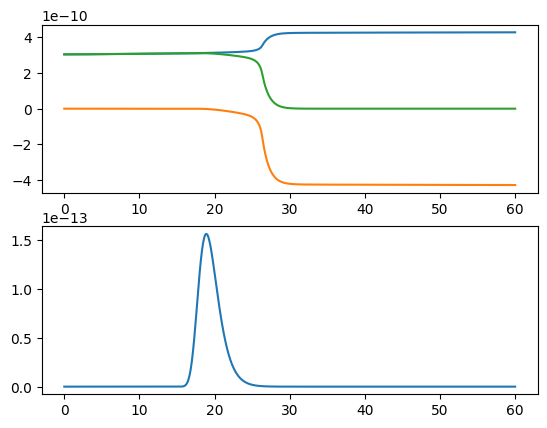

In [28]:
import matplotlib.pyplot as plt
plt.subplot(211)
plt.plot(zf/AU, np.real(Eh))
plt.plot(zf/AU, np.real(Ep))
plt.plot(zf/AU, np.real(E_m))

plt.subplot(212)
plt.plot(zf/AU, np.real(Q_m))

(-10000000000.0, 10000000000.0)

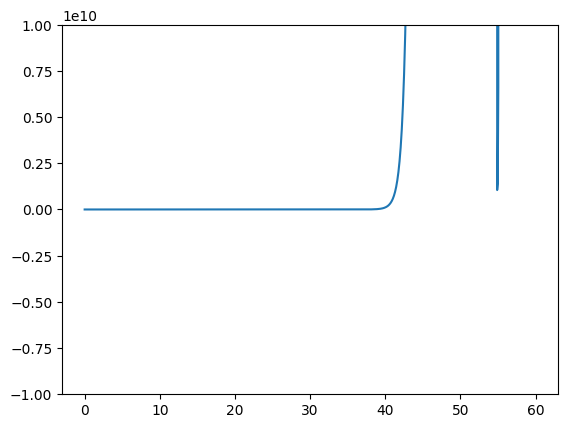

In [40]:
plt.plot(zf/AU, (np.abs(Fz_m)/(C_LIGHT*np.abs(E_m)+ 1e-300)))
plt.ylim(-1e10, 1e10)

/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/3927305085.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/3927305085.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')


(-110000.0, 110000.0)

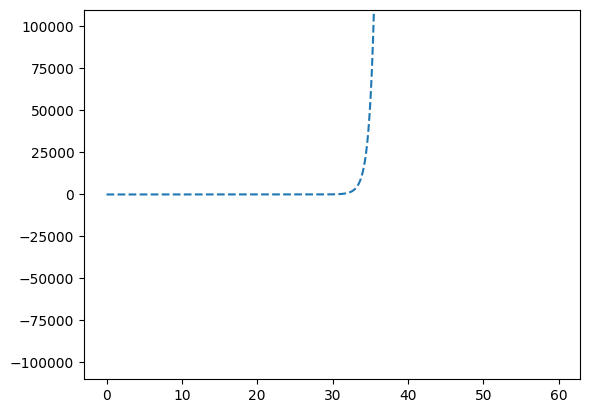

In [38]:
plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')
plt.ylim(-1.1e5, 1.1e5)

NameError: name 'D_phi' is not defined

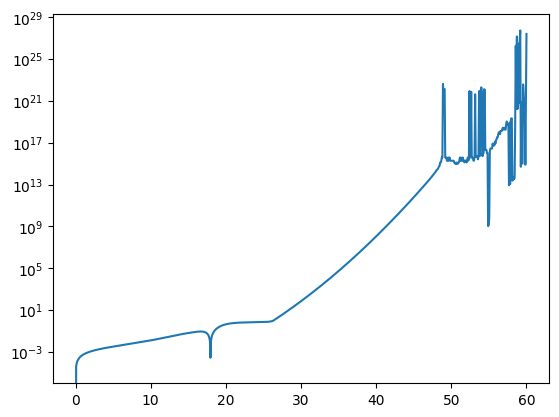

In [ ]:
fz_over_ce = np.abs(Fz_m) / (C_LIGHT*np.abs(E_m) + 1e-300)
plt.semilogy(zf/AU, fz_over_ce)



/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/2337561474.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/2337561474.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/2337561474.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_53410/2337561474.py:5: RuntimeWarning: invalid value encountered in divide
  plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')


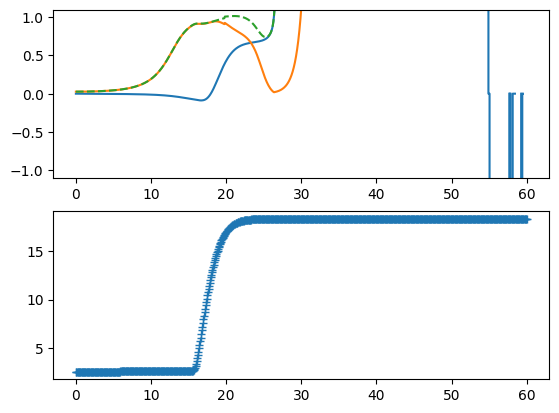

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(211)
plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))
plt.plot(zf/AU, np.real(Dfld)/R/C_LIGHT)
plt.plot(zf/AU, np.sqrt((np.real(Dfld)/R/C_LIGHT)**2 + (np.real(Fz_m)/(C_LIGHT*np.real(E_m)))**2), '--')

plt.ylim(-1.1, 1.1)

plt.subplot(212)
plt.plot(zf/AU, np.real(Td_m), '+')

In [34]:
idx_tau_disk_azi_1 = np.argmin(abs(kappaR(Tf) * np.pi* rho_d  * R-1))

NameError: name 'idx_tau_disk_azi_1' is not defined

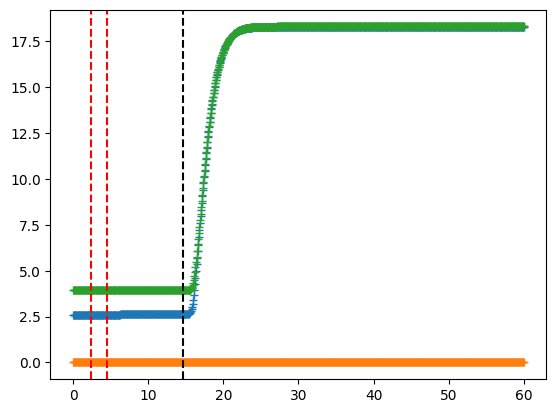

In [17]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')
plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='r', linestyle='--')
plt.ylim(0, 20)
plt.twinx()
plt.plot(zf/AU, qf)
plt.ylim(0, None)
#plt.loglog()

/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_50564/704956822.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_50564/704956822.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))


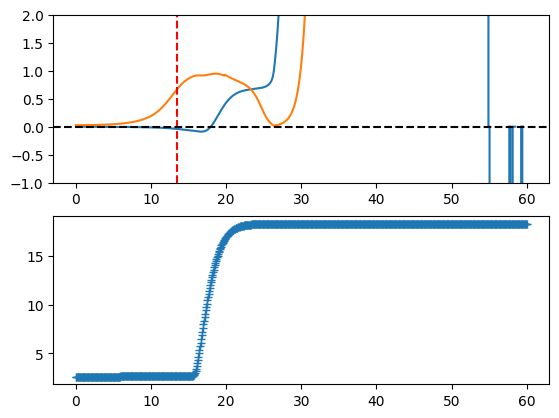

In [36]:
plt.subplot(211)
plt.plot(zf/AU, np.real(Fz_m)/(C_LIGHT*np.real(E_m)))
plt.plot(zf/AU, np.real(Dfld)/R/C_LIGHT)
plt.ylim(-1, 2)
plt.axvline(zf[idx_tau_disk_azi_1]/AU, color='r', linestyle='--')
plt.axhline(y=0, color='k', linestyle='--')

plt.subplot(212)
plt.plot(zf/AU, np.real(Td_m), '+')

(0.0, 20.0)

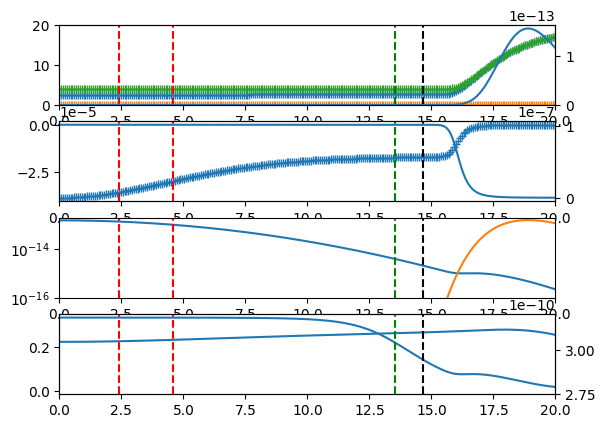

In [53]:
import matplotlib.pyplot as plt
plt.subplot(411)
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')
plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
plt.ylim(0, 20)
plt.twinx()
plt.plot(zf/AU, qf)
plt.ylim(0, None)
plt.xlim(0, 20)

plt.subplot(412)
plt.plot(zf/AU, np.angle(Td_m) * 180/np.pi, '+')
#plt.plot(zf/AU, np.angle(Tg_m)* 180/np.pi, '+')

plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
plt.xlim(0, 20)
plt.twinx()
plt.plot(zf/AU, _compute_beta_rad_d(Tf, kappaP, Omega, c_d))


plt.subplot(413)
plt.plot(z/AU, np.abs(rho_d * kappaP(Tf) * C_LIGHT * E_m))
plt.plot(z/AU, np.abs(Q_m))
plt.semilogy()
plt.ylim(1e-16, 2e-13)


plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
plt.xlim(0, 20)

plt.subplot(414)
plt.plot(z/AU, np.abs(lam))

plt.twinx()
plt.plot(zf/AU, np.real(E_m))
plt.ylim(2.75e-10, 3.2e-10)


plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
plt.xlim(0, 20)
#plt.loglog()

(0.0, 3e+25)

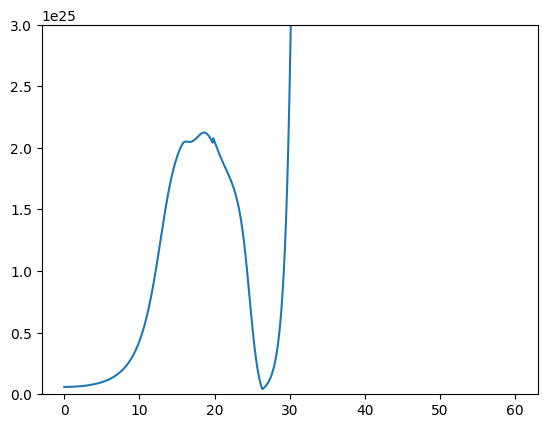

In [67]:
plt.plot(zf/AU, np.real(Dfld))
plt.ylim(0, 3e25)

(2.75e-10, 3.2e-10)

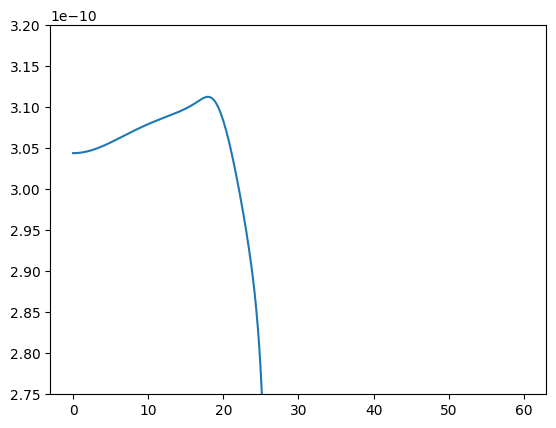

In [ ]:
plt.plot(zf/AU, np.real(E_m))
plt.ylim(2.75e-10, 3.2e-10)



[]

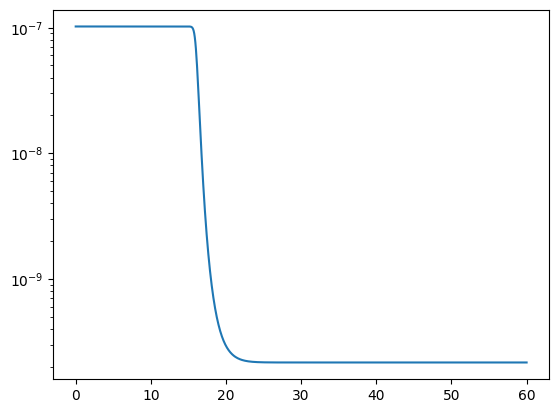

In [106]:
plt.plot(zf/AU, _compute_beta_rad_d(Tf, kappaP, Omega, c_d))
plt.semilogy()

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(311)
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')
plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
plt.ylim(0, 20)
plt.twinx()
plt.plot(zf/AU, qf)
plt.ylim(0, None)

plt.subplot(312)
plt.plot(zf/AU, np.angle(Td_m) * 180/np.pi, '+')
plt.plot(zf/AU, np.angle(Tg_m)* 180/np.pi, '+')

plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')


plt.subplot(313)
plt.plot(z/AU, np.abs(rho_d * kappaP(Tf) * C_LIGHT * E_m))
plt.plot(z/AU, np.abs(Q_m))
plt.semilogy()
plt.ylim(1e-16, 2e-13)

plt.axvline(x=zf[idx_tau_star_1]/AU, color='k', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_bottom_1]/AU, color='r', linestyle='--')
plt.axvline(x=zf[idx_tau_disk_top_1]/AU, color='r', linestyle='--')

plt.axvline(x=zf[idx_tau_disk_azi_1]/AU, color='g', linestyle='--')
#plt.loglog()

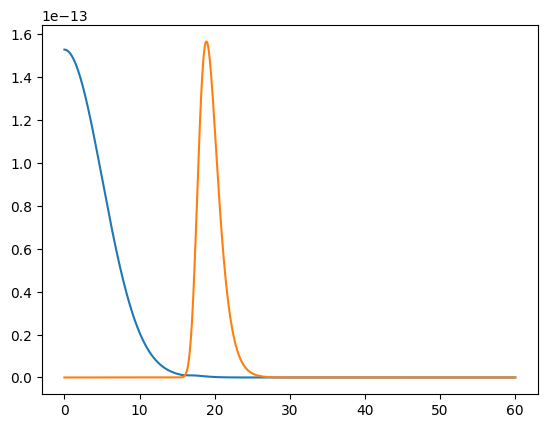

In [93]:
plt.plot(z/AU, np.abs(rho_d * kappaP(Tf) * C_LIGHT * E_m))
plt.plot(z/AU, np.abs(Q_m))

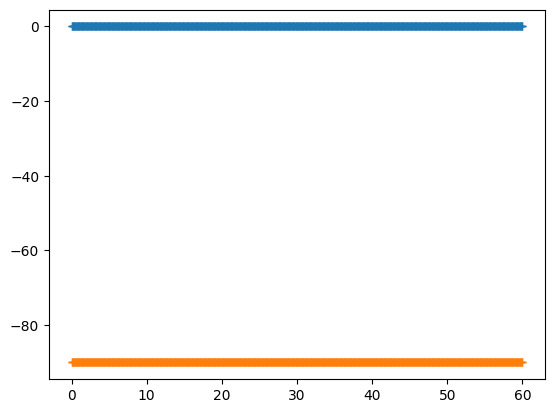

In [51]:
plt.plot(zf/AU, np.angle(Td_m) * 180/np.pi, '+')
plt.plot(zf/AU, np.angle(Tg_m)* 180/np.pi, '+')

/Users/shjzhang/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/shjzhang/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(np.float64(-30000000000.0), np.float64(30000000000.0))

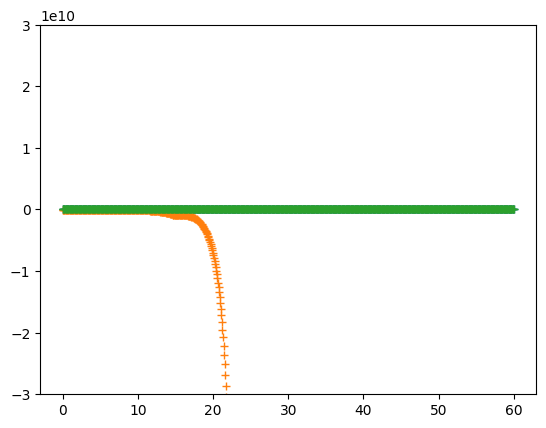

In [214]:
plt.plot(zf/AU, E_m * C_LIGHT/(4.*np.pi), '+')

plt.plot(zf/AU, np.real(-D/R*1j*m*E_m) * C_LIGHT/(4*np.pi), '+')

plt.plot(zf/AU, Fz_m / (4.*np.pi), '+')

plt.ylim(-3e10, 3e10)

plt.ylim()

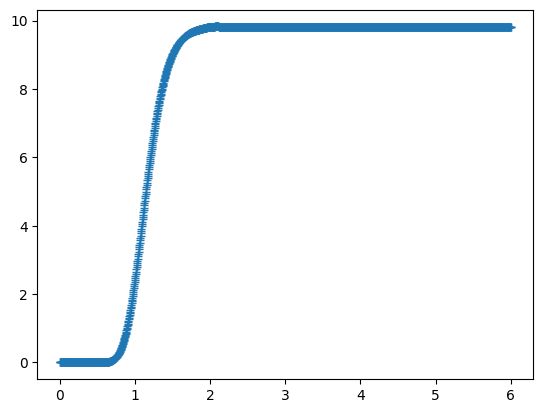

In [190]:
plt.plot(zf/AU, E_m * C_LIGHT/(4.*np.pi), '+')

(np.float64(-4.488523817246732e+37), np.float64(2.137392293927015e+36))

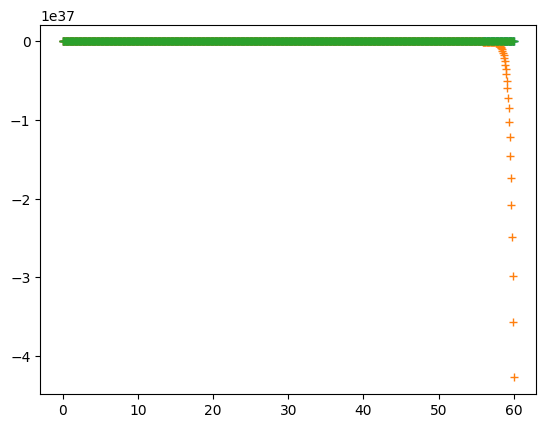

In [215]:
plt.plot(zf/AU, E_m * C_LIGHT/(4.*np.pi), '+')

plt.plot(zf/AU, np.real(-D/R*1j*m*E_m) * C_LIGHT/(4*np.pi), '+')

plt.plot(zf/AU, Fz_m / (4.*np.pi), '+')


plt.ylim()

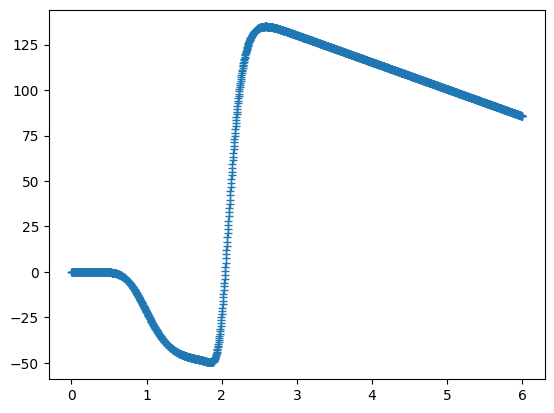

In [194]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, np.real(Fz_m) , '+')
#plt.plot(zf/AU, np.real(-D/R*1j*m*E_m) * C_LIGHT/(4*np.pi), '+')

In [ ]:
plt.plot(zf/AU, np.real(Fz_m), '+')

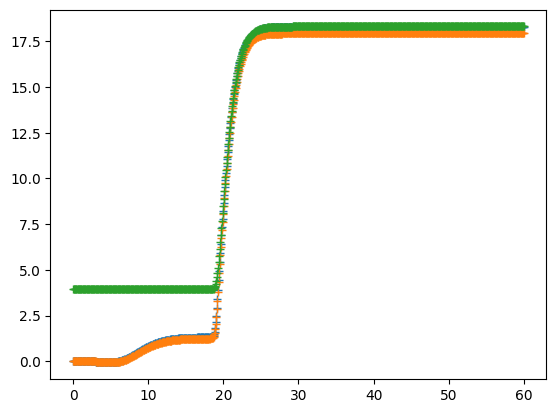

In [244]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')
#plt.loglog()

In [1]:
import matplotlib.pyplot as plt
plt.plot(zf/AU, np.real(Td_m), '+')
plt.plot(zf/AU, np.real(Tg_m), '+')
plt.plot(zf/AU, Tf/4, '+')
#plt.loglog()

NameError: name 'zf' is not defined

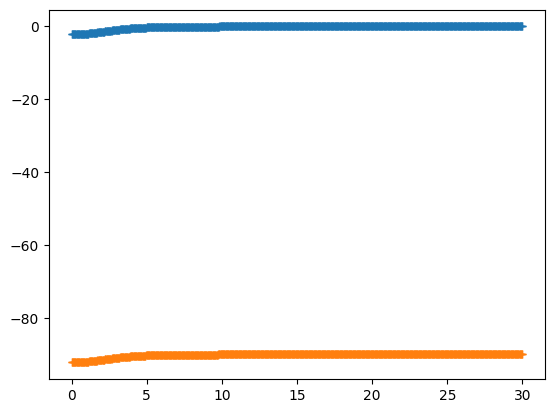

In [228]:
plt.plot(zf/AU, np.angle(Td_m) * 180/np.pi, '+')
plt.plot(zf/AU, np.angle(Tg_m)* 180/np.pi, '+')

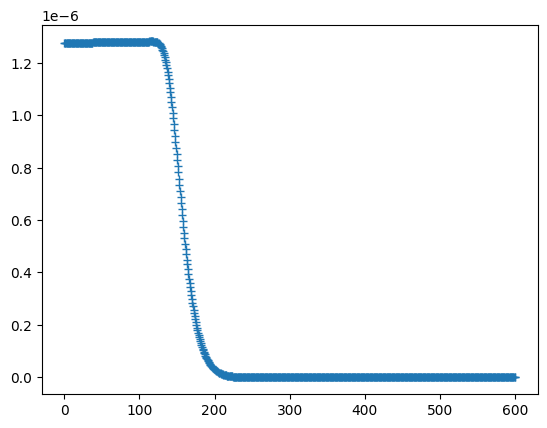

In [32]:
plt.plot(zf/AU, np.real(E_m) * C_LIGHT/(4.*np.pi), '+')

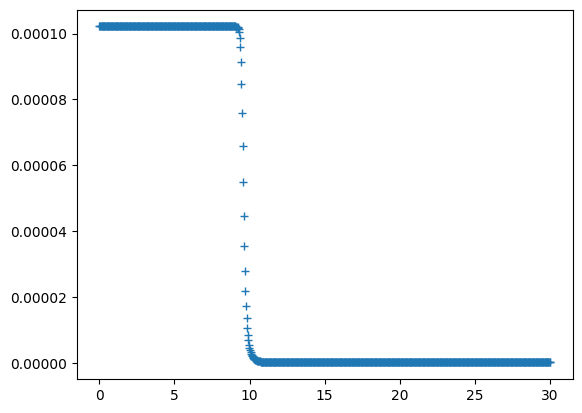

In [237]:
eta0 = 4*A_RAD*Tf**3
rhs = Q_m/(C_LIGHT*rho_d*kappaP(Tf)*eta0)
beta_rad_d = _compute_beta_rad_d(Tf, kappaP, Omega, c_d, include_dkappa_dT=False)
lhs = beta_rad_d * (Q_m/(rho_d*c_d*Omega))

plt.plot(zf/AU, beta_rad_d, '+')

#plt.plot(zf/AU, rhs + E_m/eta0, '+')

Text(0, 0.5, '1/length')

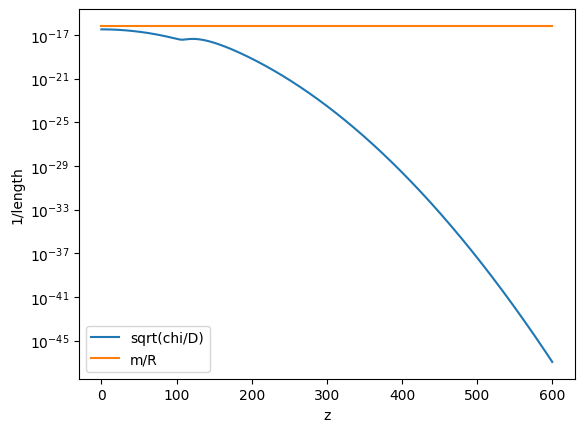

In [53]:

kapP0 = kappaP(Tf)
kapR0 = kappaR(Tf)
rho = rho_d

k_phi = m / R
k_abs = np.sqrt(3.0 * rho**2 * kapP0 * kapR0)

plt.semilogy(zf/AU, k_abs, label="sqrt(chi/D)")
plt.semilogy(zf/AU, np.ones_like(z)*k_phi, label="m/R")
plt.legend(); plt.xlabel("z"); plt.ylabel("1/length")


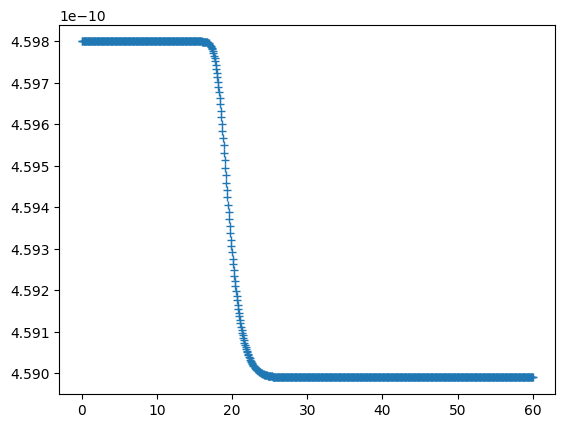

In [46]:
plt.plot(zf/AU, np.abs(Jf)/ (C_LIGHT/4/PI), '+')

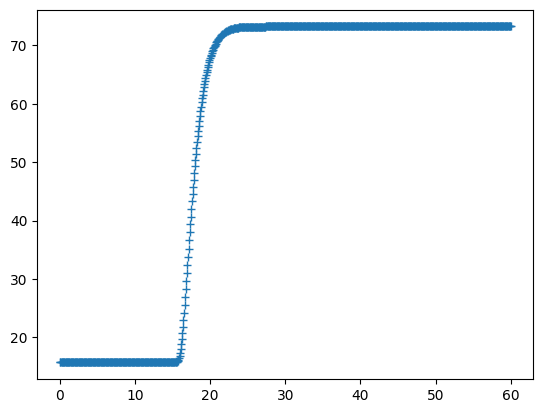

In [43]:
plt.plot(zf/AU, Tf, '+')

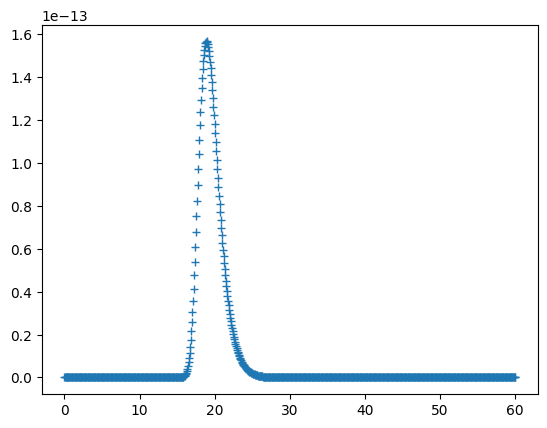

In [47]:
plt.plot(zf/AU, qf, '+')